AI ASL Identifier
---
Paulina Almada Martínez - A01710029


## Imports

In [ ]:
# Preprocesado de datos
import kagglehub
import os
import shutil
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
import tensorflow as tf
from tensorflow import keras
import numpy as np
# Red densa
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
# Red CNN
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
# Red Custom CNN
from keras.layers import MaxPooling2D

# Evaluación
import random
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Preprocesado de datos

### Obtener imágenes

Utilizamos la librería **Kagglehub** de Python para descargar las imágenes del dataset directamente de Kaggle, ya que son una cantidad considerable de archivos.

In [ ]:
path = kagglehub.dataset_download('kapillondhe/american-sign-language')

Using Colab cache for faster access to the 'american-sign-language' dataset.


Después de obtener las imágenes, porque el dataset viene distribuido en test/train pero yo quiero incrementar la cantidad de imagenes de test, debemos primero pasar todas las imágenes a una nueva carpeta en memoria de Colab.

In [ ]:
src = Path(path)
dst = Path("/content/asl_mixed") # nueva carpeta con las imágenes mezcladas
dst.mkdir(exist_ok=True)

El nombre de las imágenes es simplemente un número, con el conteo reseteando en cada carpeta. Por eso, como parte del proceso de extracción de las imágenes debemos obtener la categoría del nombre de la subcarpeta en la que está la imagen y cambiarle el nombre al label y número antes de guardarlas en nuevas carpetas de cada categoría con las originales de test y train combinadas. Esto, para facilitar trabajar con ellas más adelante y asegurar que no se sobreescriban al guardarlas.

In [ ]:
for image_path in src.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in {".jpg"}:
        label = image_path.parent.name # sacar categoría del nombre de carpeta
        label_dir = dst / label
        label_dir.mkdir(exist_ok=True) # crear nuevas carpetas por categoría con todas las imágenes
        label_name = f"{image_path.parent.parent.name}_{image_path.name}"
        shutil.copy2(image_path, label_dir / label_name)

print(f"Se encontraron {sum(len(files) for _, _, files in os.walk(dst))} imágenes")

Se encontraron 165782 imágenes


Después de crear las nuevas carpetas y renombrar las imágenes, metemos las imágenes correspondientes (basado en el label) en las nuevas carpetas.

In [ ]:
for label in sorted(os.listdir(dst)):
    count = len(os.listdir(dst / label))
    print(f"{label}: {count} imágenes")

A: 6000 imágenes
B: 6000 imágenes
C: 6000 imágenes
D: 6000 imágenes
E: 6000 imágenes
F: 6000 imágenes
G: 6000 imágenes
H: 6000 imágenes
I: 6000 imágenes
J: 6000 imágenes
K: 6000 imágenes
L: 6000 imágenes
M: 6000 imágenes
N: 6000 imágenes
Nothing: 6000 imágenes
O: 6000 imágenes
P: 6000 imágenes
Q: 6000 imágenes
R: 5970 imágenes
S: 6000 imágenes
Space: 5890 imágenes
T: 5652 imágenes
U: 4546 imágenes
V: 6000 imágenes
W: 6000 imágenes
X: 6000 imágenes
Y: 5724 imágenes
Z: 6000 imágenes


### Split test/train/val

Ya que tenemos todas las imagenes juntas y etiquetadas, realizamos el split de test, train y validation. Ya que contamos con 165,782 imágenes, definí manejar un split de **80% train** (~ 132K en total, ~ 4.7K por categoría) y **10% validation y test** (~ 16.5K en total, ~ 589 por categoría). Considero que son suficientes imágenes para que el modelo aprenda y suficiente variedad al momento de probar para comprobar que sí está funcionando correctamente.

In [ ]:
dst_split = Path("/content/asl_split") # nueva carpeta para guardarlas separadas

Después de separar las imágenes, creamos tres carpetas y guardamos las imágenes en cada una según corresponda.

In [ ]:
for label in os.listdir(dst):
  images = os.listdir(dst / label)

  # primero separar test
  rest, test = train_test_split(images, test_size=0.10, random_state=42)

  # después separar val
  train, val = train_test_split(rest, test_size=0.10, random_state=42)

  for split_name, split_files in [("train", train), ("val", val), ("test", test)]:
    split_folder = dst_split / split_name / label
    split_folder.mkdir(parents=True, exist_ok=True)
    for f in split_files:
        shutil.copy2(dst / label / f, split_folder / f)

In [ ]:
for split_name in ["train", "val", "test"]:
    for label in os.listdir(dst_split / split_name):
        count = len(os.listdir(dst_split / split_name / label))
        print(f"{split_name}/{label}: {count}")

train/Q: 4860
train/N: 4860
train/G: 4860
train/Space: 4770
train/P: 4860
train/D: 4860
train/W: 4860
train/B: 4860
train/C: 4860
train/A: 4860
train/U: 3681
train/Nothing: 4860
train/E: 4860
train/Y: 4635
train/V: 4860
train/I: 4860
train/F: 4860
train/O: 4860
train/J: 4860
train/M: 4860
train/X: 4860
train/T: 4577
train/Z: 4860
train/H: 4860
train/S: 4860
train/K: 4860
train/L: 4860
train/R: 4835
val/Q: 540
val/N: 540
val/G: 540
val/Space: 531
val/P: 540
val/D: 540
val/W: 540
val/B: 540
val/C: 540
val/A: 540
val/U: 410
val/Nothing: 540
val/E: 540
val/Y: 516
val/V: 540
val/I: 540
val/F: 540
val/O: 540
val/J: 540
val/M: 540
val/X: 540
val/T: 509
val/Z: 540
val/H: 540
val/S: 540
val/K: 540
val/L: 540
val/R: 538
test/Q: 600
test/N: 600
test/G: 600
test/Space: 589
test/P: 600
test/D: 600
test/W: 600
test/B: 600
test/C: 600
test/A: 600
test/U: 455
test/Nothing: 600
test/E: 600
test/Y: 573
test/V: 600
test/I: 600
test/F: 600
test/O: 600
test/J: 600
test/M: 600
test/X: 600
test/T: 566
test/Z

Guardamos las imágenes divididas en Google Drive para no tener que llevar a cabo todos los pasos anteriores cada vez que queremos correr el modelo. Las guardamos como un archivo zip por el gran peso de la carpeta final.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

shutil.make_archive('/content/drive/MyDrive/TC3002B/asl_split', 'zip', '/content/asl_split')

Mounted at /content/drive


'/content/drive/MyDrive/TC3002B/asl_split.zip'

### Normalización y carga de datos

Después de guardar las imágenes en Drive, podemos empezar futuras sesiones simplemente cargando las imágenes divididas.

In [58]:
drive.mount('/content/drive')
dst_split = Path("/content/asl_split")
shutil.unpack_archive('/content/drive/MyDrive/TC3002B/asl_split.zip', '/content/asl_split')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Hasta este momento, por ser un dataset pesado, hemos estado trabajando solamente con los paths de las imágenes. Ya que están divididas, las cargamos. De paso, reducimos el tamaño de las imágenes para mejorar en tiempo de rendimiento del modelo y hacemos el escalamiento de los pixeles.

In [59]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dst_split / "train",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    dst_split / "val",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    dst_split / "test",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

Found 134278 images belonging to 28 classes.
Found 14924 images belonging to 28 classes.
Found 16580 images belonging to 28 classes.


## Modelos

### 1) Modelo DNN

Como un primer acercamiento a nuestro clasificador, montamos una red nueronal densa. Por convención, utilizamos una primera capa de 128 neurones con una función de activación ReLU y una segunda capa de clasificación con una función de activación softmax. Ya que tenemos 28 categorías, montamos 28 neuronas de clasificación en esta última capa.

Nuestro modelo termina teniendo la siguiente arquitectura:

In [ ]:
model_nn = Sequential([
        Flatten(input_shape=(64, 64, 3)),
        Dense(128, activation='relu'),
        Dense(28, activation='softmax')
        ])

model_nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,604 (6.01 MB)

 Trainable params: 1,576,604 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_nn.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

Por la lentitud de procesamiento al trabajar con tantas imágenes, decidimos experimentar con solamente 5 epochs.

In [ ]:
history_nn = model_nn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5
    )

Epoch 1/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 319s 75ms/step - accuracy: 0.0358 - loss: 3.3411 - val_accuracy: 0.0362 - val_loss: 3.3312
Epoch 2/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 217s 52ms/step - accuracy: 0.0357 - loss: 3.3313 - val_accuracy: 0.0362 - val_loss: 3.3312
Epoch 3/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 205s 49ms/step - accuracy: 0.0354 - loss: 3.3314 - val_accuracy: 0.0362 - val_loss: 3.3311
Epoch 4/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 212s 50ms/step - accuracy: 0.0361 - loss: 3.3313 - val_accuracy: 0.0362 - val_loss: 3.3312
Epoch 5/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 208s 50ms/step - accuracy: 0.0357 - loss: 3.3313 - val_accuracy: 0.0362 - val_loss: 3.3312


#### Evaluación del modelo

Después de realizar un primer entrenamiento del modelo con los datos de train y una prueba inicial con los datos de validación, podemos ver a simple vista que el modelo tiene un muy bajo rendimiento. Su train accuracy se mantiene entre 0.0350 y 0.0362, mientras que su val accuracy se mantiene consistentemente en 0.0362. En otras palabras, en ambos casos no supera el 3%. Por otro lado, el loss en training igualmente se mantiene muy alto, solamente bajando después del primer epoch y no cambiando después. En la validación, el loss tal cual no cambia. En ambos casos, se mantiene por encima de 3.

In [ ]:
acc = history_nn.history['accuracy']
val_acc = history_nn.history['val_accuracy']
loss = history_nn.history['loss']
val_loss = history_nn.history['val_loss']

epochs = range(1, len(acc)+1)

Podemos visualizar la tendencia de accuracy y loss que identificamos de una manera más visual con las siguientes gráficas, que nos permiten ver esencialmente que ninguno de los dos valores cambia significativamente durante los epochs del entrenamiento. En otras palabras, el modelo no está realmente aprendiendo.

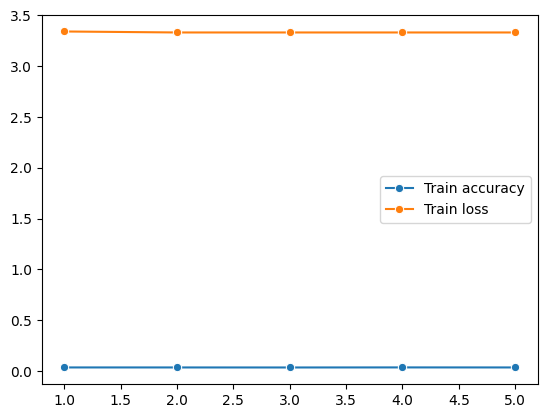

In [ ]:
ax = sns.lineplot(x=epochs, y=acc, label="Train accuracy", marker="o")
sns.lineplot(x=epochs, y=loss, label="Train loss", ax=ax, marker="o")

plt.legend()
plt.show()

Notamos esta misma tendencia con los datos de validación. Esto tiene sentido, ya que si nuestro modelo no aprendió de los datos de entrenamiento, claramente no va a poder distinguir bien los símbolos ni mejorar su rendimiento al momento de la validación.

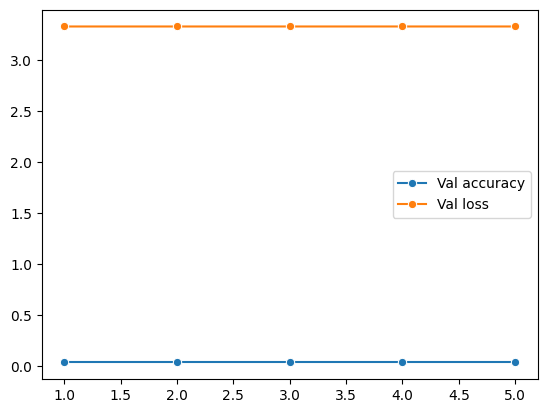

In [ ]:
ax = sns.lineplot(x=epochs, y=val_acc, label="Val accuracy", marker="o")
sns.lineplot(x=epochs, y=val_loss, label="Val loss", ax=ax, marker="o")

plt.legend()
plt.show()

#### **Diagnóstico final**: underfitting

Claramente, nuestro modelo tiene un accuracy catastróficamente bajo y un loss que no cambia a lo largo de los epochs. Esto nos indica que nuestro modelo no está aprendiendo a base de nuestros datos de entrenamiento, por lo que nunca nos podrá dar resultados útiles al menos de que realicemos cambios importantes en la arquitectura para ayudarle a ajustarse mejor a los datos.

En particular, un rendimiento así de bajo con un modelo así de simple nos indica que el problema principal es que la arquitectura es demasiado simple para el problema que queremos resolver. Por eso, vamos a implementar las siguientes estrategias para nuestra siguiente iteración:

- Implementar una arquitectura más compleja (CNN)
- Incrementar el número de nodos en la capa interna densa

### 2) Modelo CNN

Como un primer acercamiento a una arquitectura capaz de manejar el dataset con el que estamos trabajando, montamos un CNN, el cual es comúnmente utilizado para clasificación de símbolos ASL en la literatura, aunque típicamente se agregan más elementos a su arquitectura como capas convolucionales o de pooling [[^1]](https://onlinelibrary.wiley.com/doi/epdf/10.1002/eng2.12878?getft_integrator=scopus&src=getftr)[[^5]](https://ieeexplore.ieee.org/document/9230772) o utilizar una estructura siamesa para calcular similitud entre embeddings de cada símbolo [[^4]]().

Para comprender mejor cómo el cambio de arquitectura afecta el rendimiento del modelo, primero realizamos una implementación "vainilla" sobre la que vamos a iterar y mejorar más adelante. Esta implementación vainilla esencialmente agrega una capa convolutiva y más neuronas a nuestro modelo DNN:

In [60]:
model_cnn = models.Sequential()
model_cnn.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (64, 64, 3)))
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(256, activation='relu'))
model_cnn.add(layers.Dense(28, activation='softmax'))

model_cnn.summary()

model_cnn.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 38440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,840,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,848,372 (37.57 MB)

 Trainable params: 9,848,372 (37.57 MB)

 Non-trainable params: 0 (0.00 B)

Para tener una comparación de rendimiento justa, mantenemos los cinco epochs.

In [61]:
history_cnn = model_cnn.fit(
						train_generator,
            validation_data=val_generator,
						epochs = 5)

Epoch 1/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 312s 74ms/step - accuracy: 0.5192 - loss: 1.7384 - val_accuracy: 0.6768 - val_loss: 1.1650
Epoch 2/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 270s 64ms/step - accuracy: 0.7257 - loss: 0.9769 - val_accuracy: 0.7592 - val_loss: 0.8243
Epoch 3/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 216s 51ms/step - accuracy: 0.7993 - loss: 0.7083 - val_accuracy: 0.8323 - val_loss: 0.5938
Epoch 4/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 229s 55ms/step - accuracy: 0.8426 - loss: 0.5492 - val_accuracy: 0.8805 - val_loss: 0.4548
Epoch 5/5
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 212s 50ms/step - accuracy: 0.8728 - loss: 0.4420 - val_accuracy: 0.8256 - val_loss: 0.5092


Inmediatamente notamos una mejora significativa en el rendimiento con este nuevo modelo. Su train accuracy sube de 0.5192 hasta 0.8728, mientras que su val accuracy sube de 0.6768 hasta 0.8256. En ambos casos, vemos un crecimiento constante en los valores, con un drop pequeño pero interesante en el accuracy de val entre los epochs 4 y 5. Por otro lado, el loss en training igualmente baja progresivamente en ambos casos. En la validación, el loss también tiene una subida que llama la atención entre los epochs 4 y 5.

#### Resultados con test

Ya que tuvimos resultados fiables con este modelo (>70% accuracy), procedemos a generar predicciones con nuestros datos de prueba para evaluar en su totalidad al modelo.

In [62]:
test_loss, test_acc = model_cnn.evaluate(test_generator)

519/519 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.8233 - loss: 0.5139


In [63]:
predictions = model_cnn.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
categories = list(test_generator.class_indices.keys())

519/519 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step


Tuvimos un buen rendimiento igualmente con test, esencialmente equivalente al rendimiento con val. Para confirmar cómo se está comportante nuestro modelo, imprimimos imágenes del batch evaluado junto con su predicción y su categoría real.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


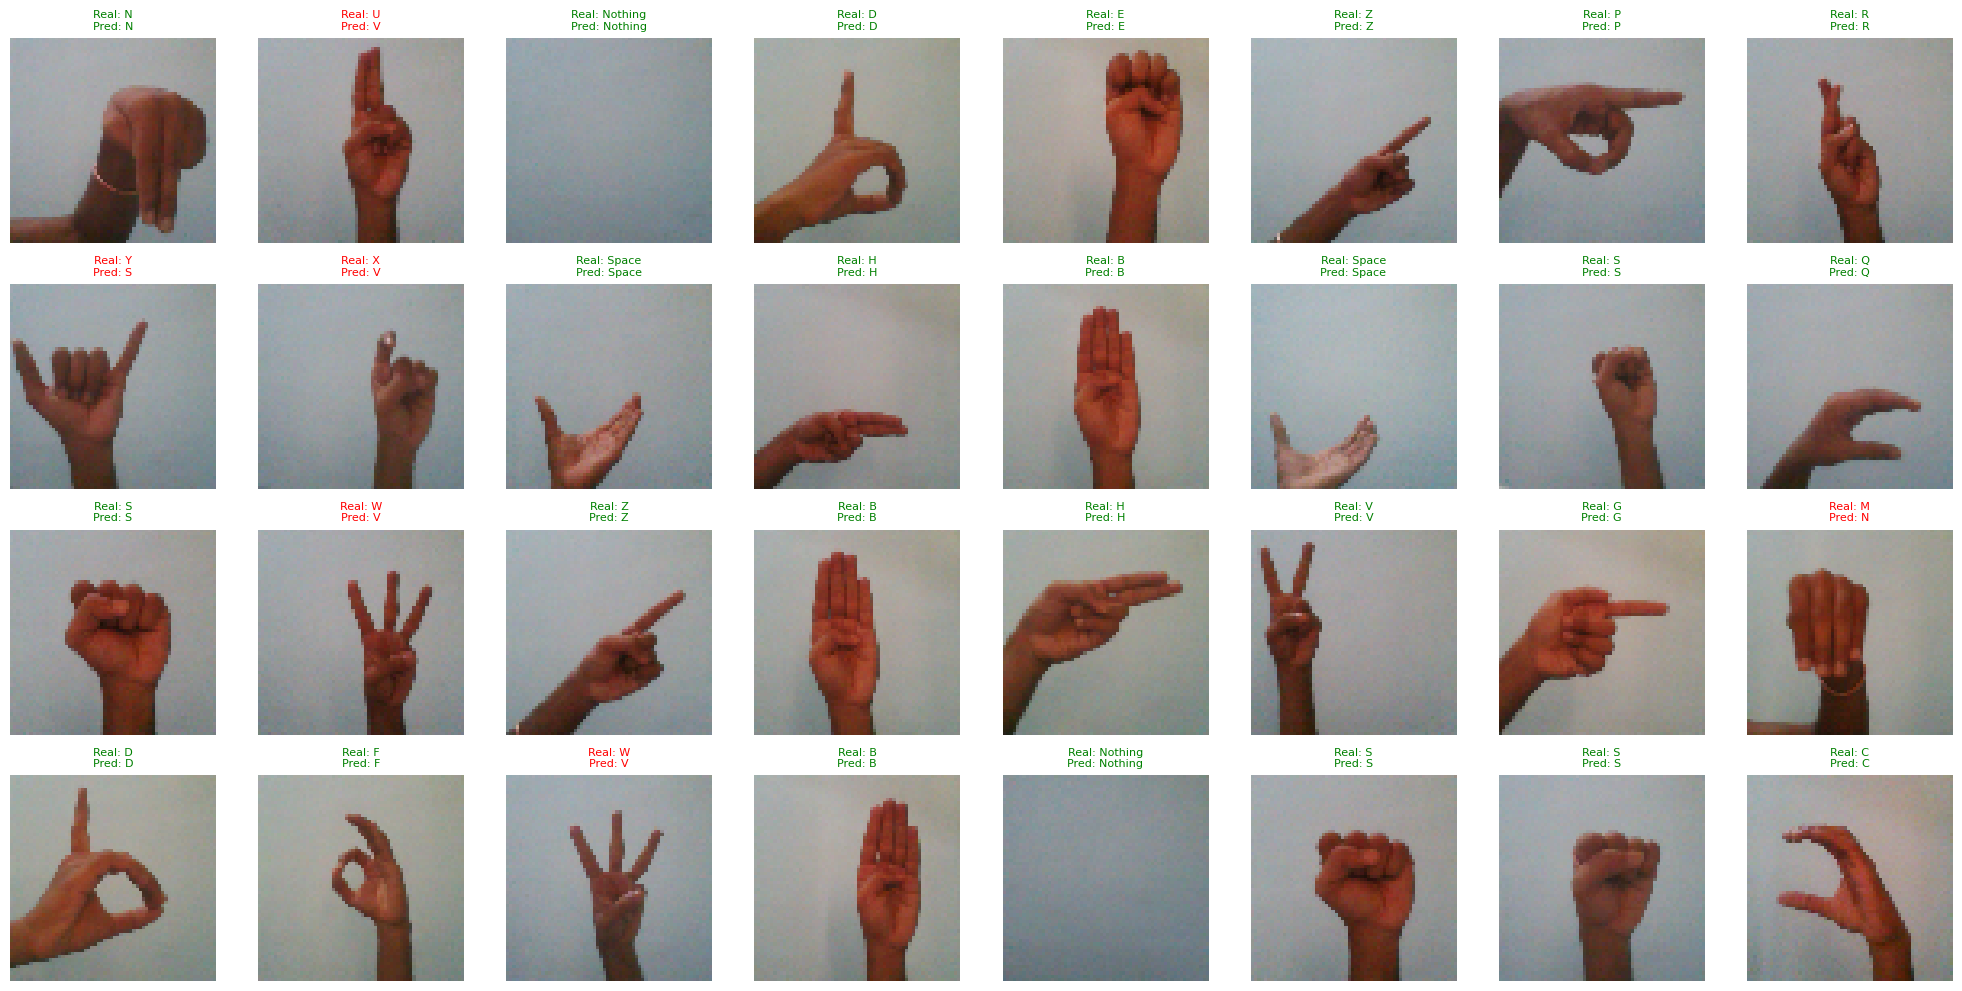

In [64]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

# Tomar imágenes del primer batch para visualizar
test_generator.reset()
imgs, labels = next(test_generator)
preds = model_cnn.predict(imgs)

for i, ax in enumerate(axes):
    if i >= len(imgs):
        break
    ax.imshow(imgs[i])
    true_label = categories[np.argmax(labels[i])]
    pred_label = categories[np.argmax(preds[i])]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"Real: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

Podemos notar que ciertas categorías aparecen consistentemente como erróneas en este primer batch. Por eso, vamos a examinar el rendimiento por categoría más adelante.

#### Evaluación del modelo

Procedemos a visualizar los patrones de accuracy y los que notamos anteriormente durante el entrenamiento. En train, el modelo se comporta exactamente como esperamos de un buen modelo, donde el accuracy y el loss bajan en conjunto.

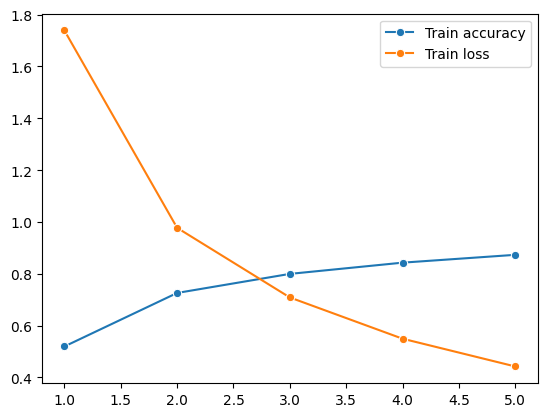

In [ ]:
ax = sns.lineplot(x=epochs, y=acc, label="Train accuracy", marker="o")
sns.lineplot(x=epochs, y=loss, label="Train loss", ax=ax, marker="o")

plt.legend()
plt.show()

En val, visualizamos que el accuracy baja en el último epoch, en conjunto con el loss subiendo en ese mismo epoch. Esto es interesante, ya que nos indica que posiblemente existe un problema con el ajuste de los datos cuando el modelo interactúa con datos con los que no entrenó.

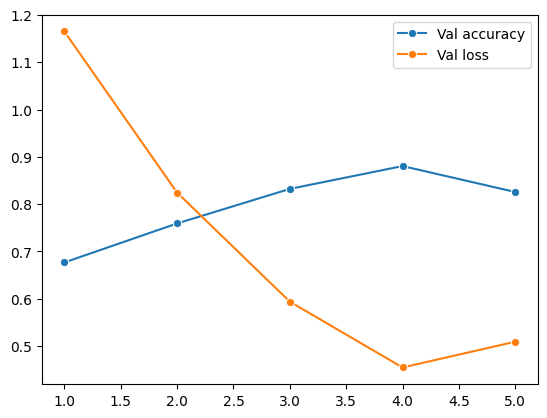

In [ ]:
ax = sns.lineplot(x=epochs, y=val_acc, label="Val accuracy", marker="o")
sns.lineplot(x=epochs, y=val_loss, label="Val loss", ax=ax, marker="o")

plt.legend()
plt.show()

Como mencionamos anteriormente, también revisamos el comportamiento del modelo en cada categoría para identificar cuáles tienen underfitting que esté afectando al modelo. Utilizamos precisión, recall y F1 Score como métricas para tener un panomara más completo del comportamiento de las predicciones. Identificamos las siguientes categorías con los siguientes problemas:

* **R** tiene una precisión de 0.88 y un recall de 0.34. El modelo no está encontrando R lo suficiente, pero generalmente es capaz de reconocerlo cuando lo encuentra.
* **S** tiene una precisión de 0.51 y un recall de 0.9. El modelo está prediciendo S de más.
* **U** tiene una precisión de 1 y un recall de 0.02. El modelo casi nunca encuentra la letra U, pero nunca asigna esa predicción a una letra que no corresponde. Es notable que U es la letra menor representada en el dataset.
* **V** tiene una precisión de 0.25 y un recall de 1. Todas las instancias de V se están encontrando, pero también varios símbolos que no son V se están prediciendo como si fueran V.
* **W** tiene una precisión de 0.5 y un recall de 0.01. Este símbolo es el que más le está costando al modelo, ya que casi nunca lo encuentra y utiliza este símbolo como predicción errónea en otras letras.
* **X** tiene una precisión de 0.98 y un recall de 0.41. El modelo le está costando encontrar el símbolo, pero rara vez lo predice incorrectamente.
* **Y** tiene una precisión de 1 y un recall de 0.77. El modelo siempre predice este símbolo correctamente, pero no siempre lo encuentra.

In [ ]:
print(classification_report(y_true, y_pred, target_names=categories))

              precision    recall  f1-score   support

           A       0.99      0.90      0.95       600
           B       0.92      0.93      0.93       600
           C       0.96      1.00      0.98       600
           D       0.96      0.99      0.97       600
           E       0.85      0.91      0.88       600
           F       0.97      0.96      0.97       600
           G       0.98      0.91      0.94       600
           H       0.95      0.98      0.97       600
           I       0.93      0.84      0.88       600
           J       0.96      0.97      0.96       600
           K       0.99      0.82      0.90       600
           L       0.89      0.95      0.92       600
           M       0.96      0.85      0.90       600
           N       0.93      0.92      0.93       600
     Nothing       1.00      1.00      1.00       600
           O       0.96      0.83      0.89       600
           P       1.00      0.97      0.98       600
           Q       0.97    

Agregamos la Confusion Matrix como una métrica de evaluación para identificar cuáles categorías se están asignando de manera errónea con cuáles otras para explicar el bajo recall que encontramos. Utilizamos esta métrica en particular porque es muy útil para determinar si el rendimiento del modelo es parejo entre cada categoría o si hay categorías de clasificación débiles [[3]](https://www.mdpi.com/1424-8220/25/7/2138).

Con esta matriz, identificamos los siguientes patrones importantes:
* **R** se confunde principalmente por **V**.
* **T** se confunde principalmente por **S**.
* **U** se confunde principalmente por **V**.
* **W** se confunde principalmente por **V**.
* **X** se confunde principalmente por **S** y **V**. Se confunde más por S.
* **Y** se confunde principalmente por **S** y **V**. Se confunde más por S.

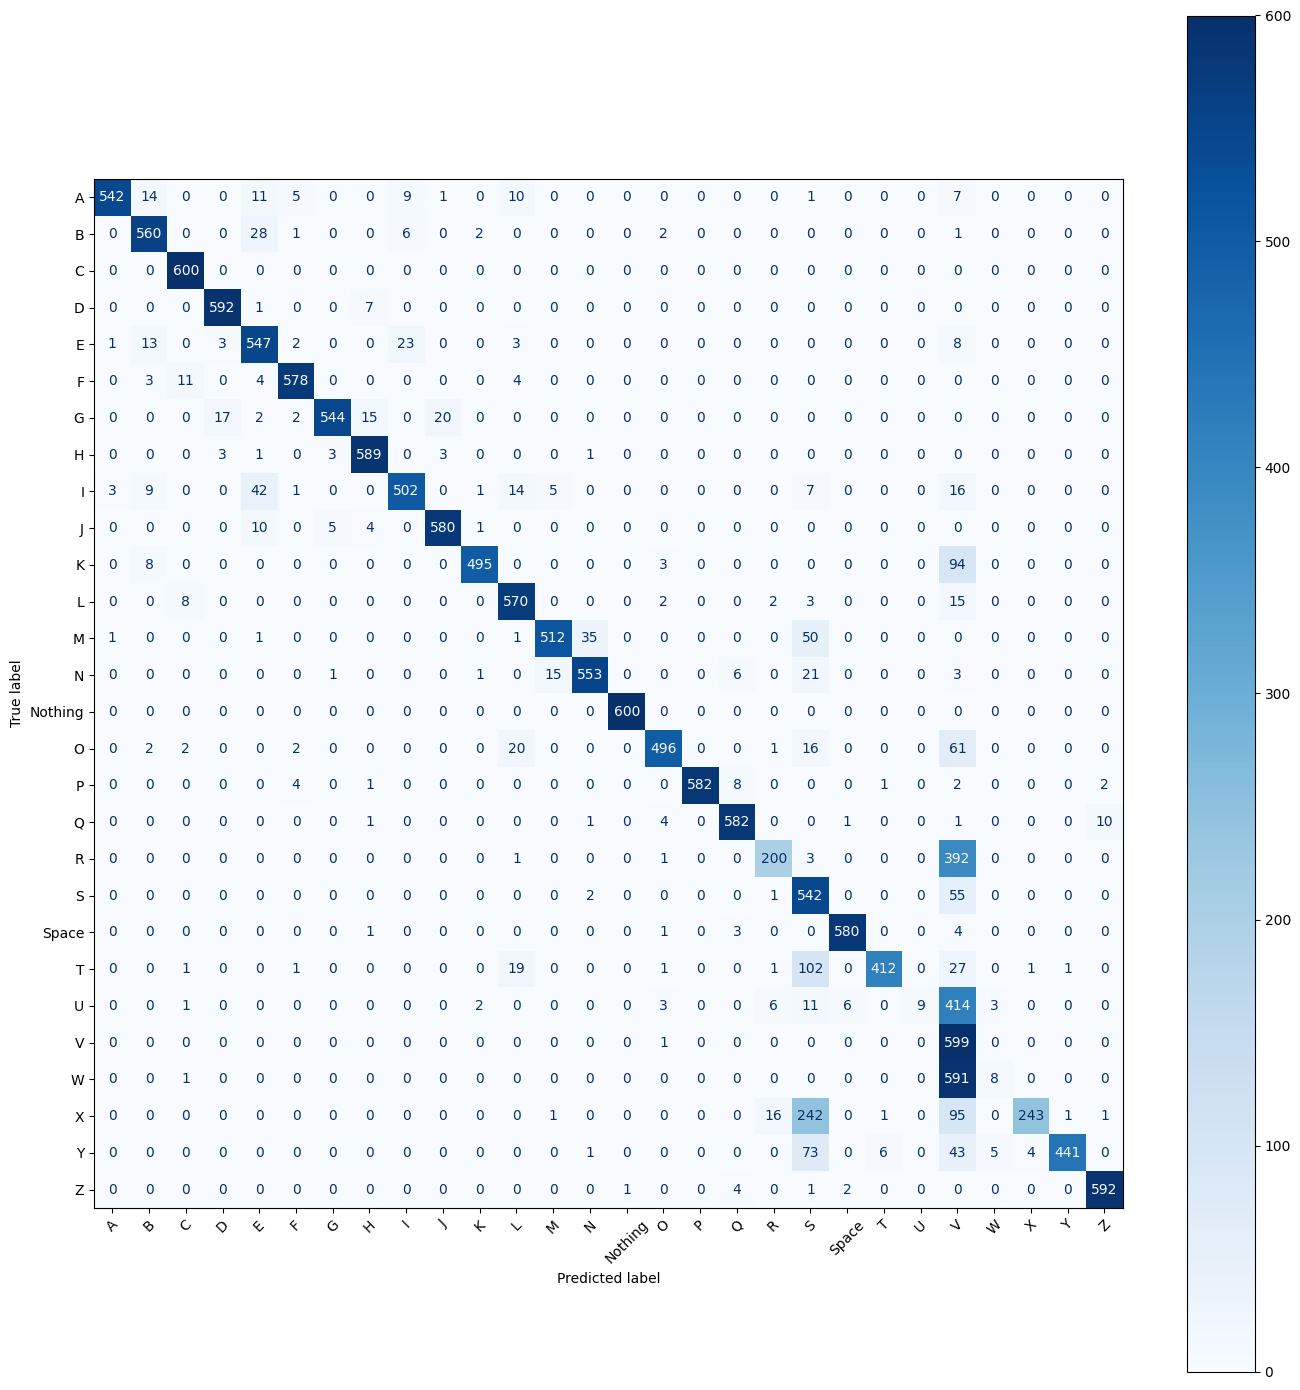

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.tight_layout()
plt.show()

También analizamos el accuracy por categoría, ya que es nuestra métrica principal [[1]](https://onlinelibrary.wiley.com/doi/epdf/10.1002/eng2.12878?getft_integrator=scopus&src=getftr)[[2]](https://iapress.org/index.php/soic/article/view/2020/1120)[[3]](https://www.mdpi.com/1424-8220/25/7/2138)[[4]]()[[5]](https://ieeexplore.ieee.org/document/9230772).

Encontramos los siguientes patrones:
* **U** y **W** tienen accuracies catastróficamente bajos, indicando que el modelo no los aprendió
* **R** y **X** tienen accuracies bajos y alarmantes
* **T** y **Y** también se encuentran por debajo del promedio, así que igual requieren más atención

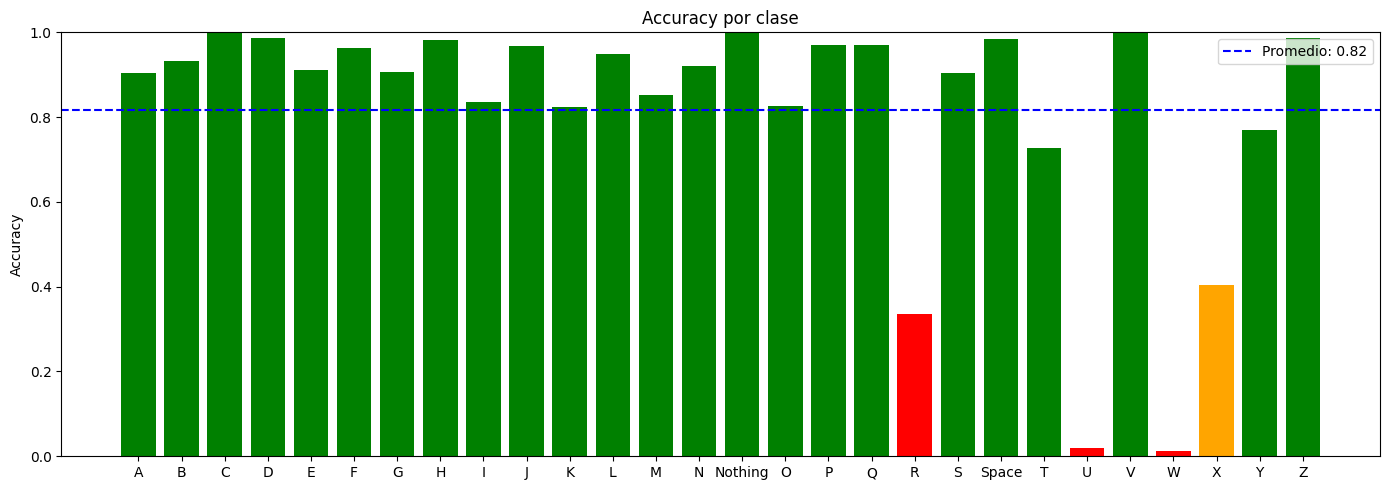

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(14, 5))
bars = plt.bar(categories, per_class_acc, color=['green' if a > 0.7 else 'orange' if a > 0.4 else 'red' for a in per_class_acc])
plt.axhline(y=per_class_acc.mean(), color='blue', linestyle='--', label=f'Promedio: {per_class_acc.mean():.2f}')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy por clase")
plt.legend()
plt.tight_layout()
plt.show()

#### **Diagnóstico final**: underfitting

Nuestro modelo tiene un accuracy mucho mejor, pero el accuracy de train es mayor al accuracy de val y test. Además, al revisar el rendimiento en símbolos específicos, hay ciertos símbolos con rendimientos catastróficamente malos. Esto nos indica que nuestro modelo no está aprendiendo ciertas categorías y siguen existiendo áreas de mejora en la arquitectura para tener un modelo aún más fiable.

Por eso, vamos a implementar las siguientes estrategias para nuestra siguiente iteración:

- Implementar más capas convolutivas con más filtros para un mayor procesamiento y aprendizaje de los datos
- Agregar capas de max pooling para no tener un vector tan masivo

### 3) Modelo Custom CNN

Para esta mejora sobre el modelo anterior, nos vamos a enfocar en mejorar la habilidad del modelo de distinguir entre categorías. Por eso, vamos a agregar una segunda capa convolutiva que distingue específicamente estas categorías [[1]]( https://onlinelibrary.wiley.com/doi/epdf/10.1002/eng2.12878?getft_integrator=scopus&src=getftr). Además, vamos a agregar capas de MaxPooling 2D para obtener un embedding menos complejo de procesar pero más representativo [[2]](https://iapress.org/index.php/soic/article/view/2020/1120).

In [ ]:
model_ccnn = models.Sequential()
model_ccnn.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (64, 64, 3)))
model_ccnn.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"))
model_ccnn.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (31, 31, 3)))
model_ccnn.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"))
model_ccnn.add(layers.Flatten())
model_ccnn.add(layers.Dense(128, activation='relu'))
model_ccnn.add(layers.Dense(96, activation='relu'))
model_ccnn.add(layers.Dense(28, activation='softmax'))

model_ccnn.summary()

model_ccnn.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         2,716 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,188 (3.16 MB)

 Trainable params: 828,188 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

Otro cambio que vamos a implementar es aplicamos el doble de epochs. Aunque la literatura utiliza 30 epochs [[1]](https://onlinelibrary.wiley.com/doi/epdf/10.1002/eng2.12878?getft_integrator=scopus&src=getftr)[[4]](), ya que 5 epochs han estado dando buenos resultados y tenemos limitaciones de hardware, vamos a aplicar **10 epochs**.

In [ ]:
history_ccnn = model_ccnn.fit(
						train_generator,
            validation_data=val_generator,
						epochs = 10)

Epoch 1/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 281s 67ms/step - accuracy: 0.4181 - loss: 2.1172 - val_accuracy: 0.5798 - val_loss: 1.5008
Epoch 2/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 225s 54ms/step - accuracy: 0.6501 - loss: 1.2233 - val_accuracy: 0.7259 - val_loss: 0.9731
Epoch 3/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 220s 52ms/step - accuracy: 0.7574 - loss: 0.8289 - val_accuracy: 0.7861 - val_loss: 0.7148
Epoch 4/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 219s 52ms/step - accuracy: 0.8278 - loss: 0.5889 - val_accuracy: 0.8681 - val_loss: 0.4862
Epoch 5/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 219s 52ms/step - accuracy: 0.8758 - loss: 0.4318 - val_accuracy: 0.8945 - val_loss: 0.3712
Epoch 6/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 216s 52ms/step - accuracy: 0.9078 - loss: 0.3252 - val_accuracy: 0.9255 - val_loss: 0.2782
Epoch 7/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 214s 51ms/step - accuracy: 0.9292 - loss: 0.2513 - val_accuracy: 0.9437 - val_loss: 0.2074
Epoch 8/10
4197/4197 ━━━━━━━━━━━━━━━━━━━━ 226s 54ms/step - accuracy: 

De nuevo notamos una mejora significativa en el rendimiento. El train accuracy subre de 0.4181 hasta 0.9650, mientras que el val accuracy subre de 0.5798 hasta 0.9733. Tanto para accuracy como para loss, se nota un rendimiento ligeramente mejor en validación.

#### Resultados con test

In [ ]:
test_loss, test_acc = model_ccnn.evaluate(test_generator)

519/519 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.9715 - loss: 0.1115


In [ ]:
predictions = model_ccnn.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
signs = list(test_generator.class_indices.keys())

519/519 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step


Confirmamos que nuestro modelo igualmente tiene un buen rendimiento con test. Su accuracy es muy parecido al accuracy de val. Revisamos el comportamiento del batch comparado con las imágenes con las que se está evaluando para ver las diferencias.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


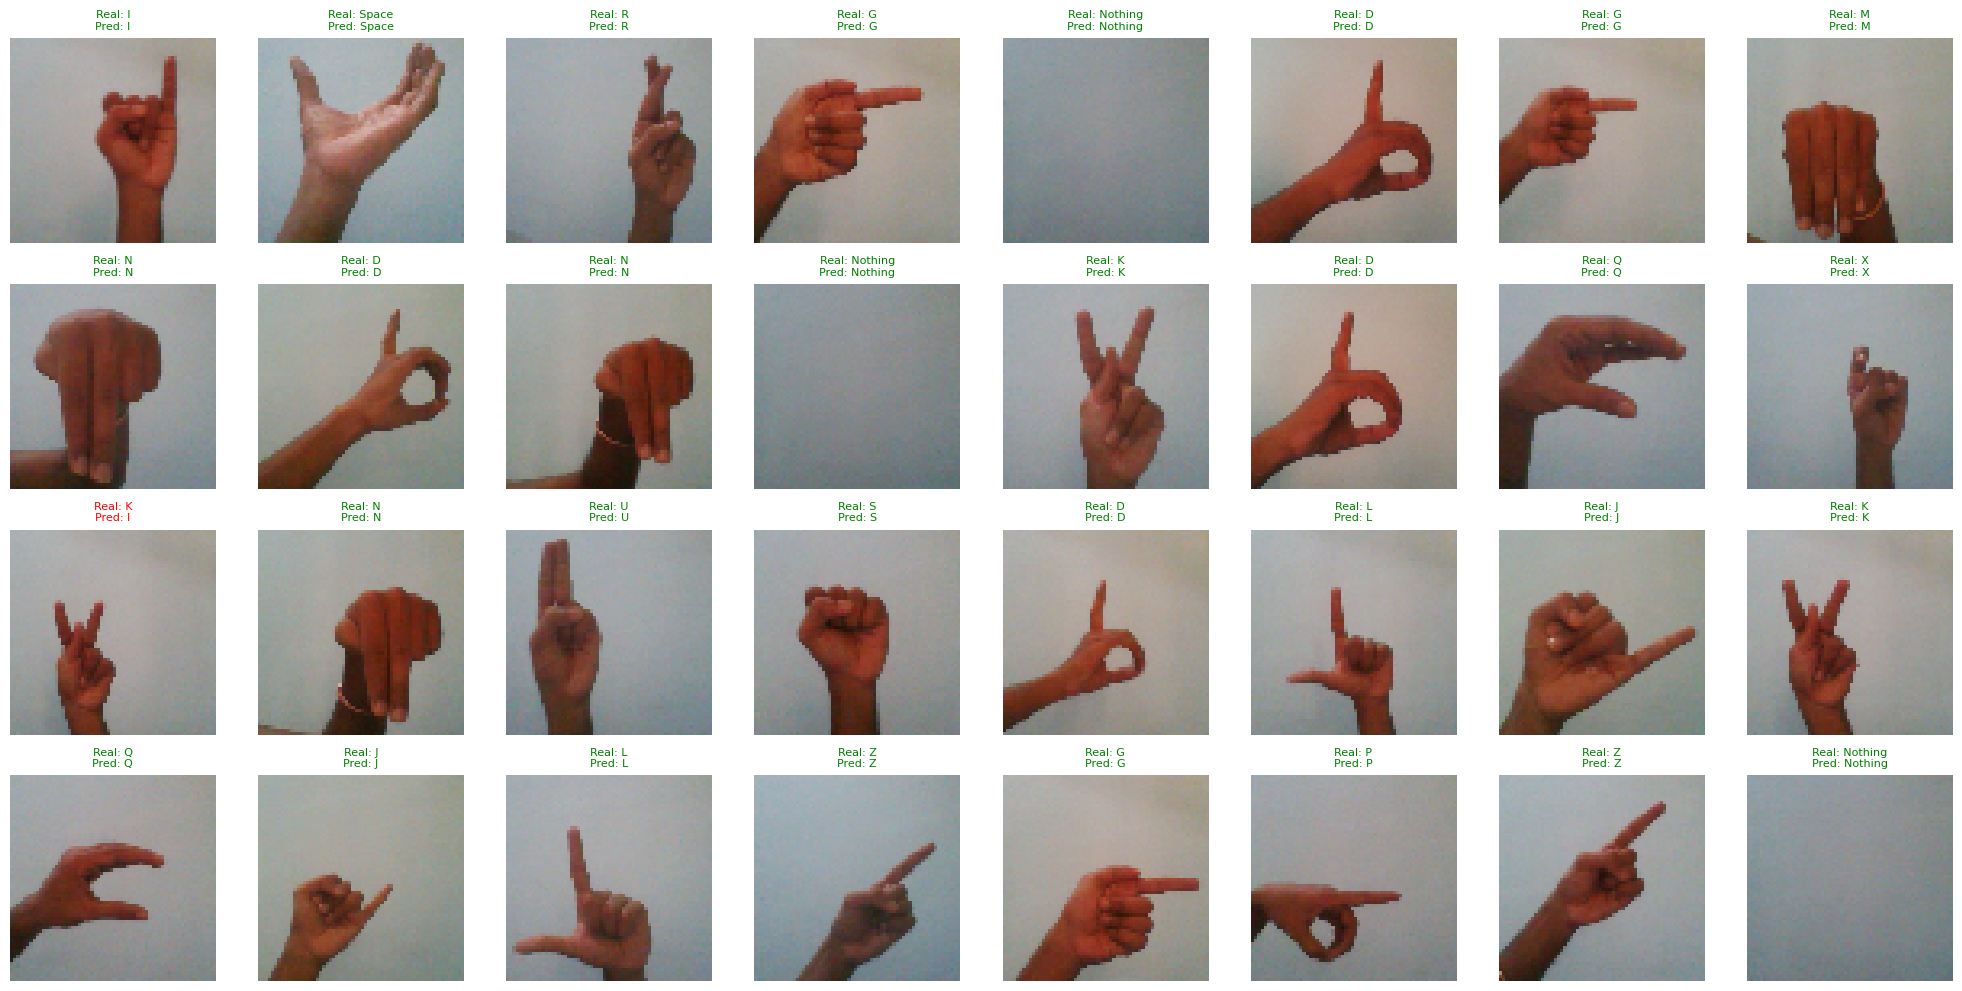

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

# Tomar imágenes del primer batch para visualizar
test_generator.reset()
imgs, labels = next(test_generator)
preds = model_ccnn.predict(imgs)

for i, ax in enumerate(axes):
    if i >= len(imgs):
        break
    ax.imshow(imgs[i])
    true_label = signs[np.argmax(labels[i])]
    pred_label = signs[np.argmax(preds[i])]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"Real: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

Notamos que solamente una categoría tiene un error, que es una de las categorías que ya teníamos identificadas del modelo anterior como una categoría que requiere mayor atención. Revisamos el rendimiento por categoría más adelante.

#### Evaluación del modelo

In [ ]:
acc = history_ccnn.history['accuracy']
val_acc = history_ccnn.history['val_accuracy']
loss = history_ccnn.history['loss']
val_loss = history_ccnn.history['val_loss']

epochs = range(1, len(acc)+1)

Visualizando el comportamiento de accuracy y loss, notamos que de nuevo presentamos un comportamiento esperado en train.

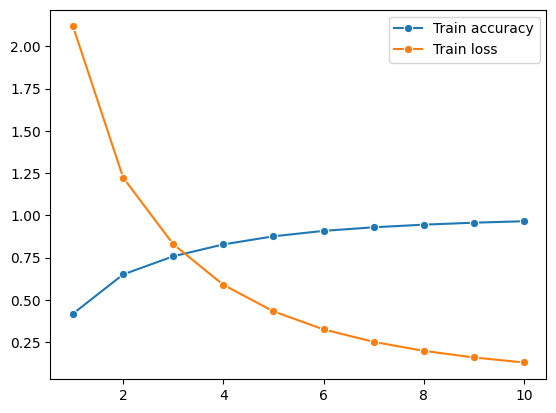

In [ ]:
ax = sns.lineplot(x=epochs, y=acc, label="Train accuracy", marker="o")
sns.lineplot(x=epochs, y=loss, label="Train loss", ax=ax, marker="o")

plt.legend()
plt.show()

En val, notamos que de nuevo tuvimos un crecimiento ligero en loss en la penúltima epoch, pero es menor que en el modelo pasado.

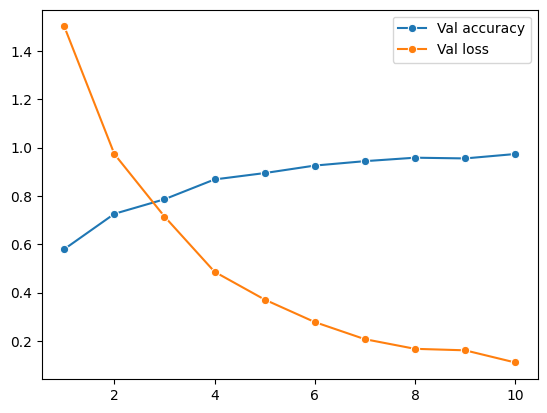

In [ ]:
ax = sns.lineplot(x=epochs, y=val_acc, label="Val accuracy", marker="o")
sns.lineplot(x=epochs, y=val_loss, label="Val loss", ax=ax, marker="o")

plt.legend()
plt.show()

Ahora revisamos el comportamiento del modelo en cada categoría para revisar las mejoras que hubo e identificar si aún hay categorías débiles. Idenficamos los siguientes cambios:

* **R** tiene una precisión de 0.96 y un recall de 0.89. Mejoró bastante su habilidad de encontrar este símbolo.
* **S** tiene una precisión de 0.85 y un recall de 0.98. Es más preciso al predecir este símbolo.
* **U** tiene una precisión de 0.89 y un recall de 0.93. Aunque bajó su precisión, que antes era 1, subió importantemente su recall.
* **V** tiene una precisión de 0.83 y un recall de 0.99. Este es el símbolo con la precisión más baja del dataset.
* **W** tiene una precisión de 0.98 y un recall de 0.89. Este símbolo es el que más mejoró.
* **X** tiene una precisión de 0.99 y un recall de 0.85. La precisión mejoró ligeramente junto con un aumento importante en el recall.
* **Y** tiene una precisión de 1 y un recall de 0.99. El modelo sigue siempre prediciendo este símbolo correctamente, pero ahora también casi siempre lo encuentra.

In [ ]:
print(classification_report(y_true, y_pred, target_names=signs))

              precision    recall  f1-score   support

           A       0.99      0.99      0.99       600
           B       1.00      0.99      1.00       600
           C       0.98      1.00      0.99       600
           D       1.00      1.00      1.00       600
           E       0.98      0.97      0.98       600
           F       1.00      1.00      1.00       600
           G       0.97      0.99      0.98       600
           H       0.99      1.00      0.99       600
           I       0.97      0.98      0.98       600
           J       0.98      0.97      0.98       600
           K       1.00      0.97      0.98       600
           L       0.98      0.98      0.98       600
           M       0.96      0.98      0.97       600
           N       0.99      0.94      0.97       600
     Nothing       1.00      1.00      1.00       600
           O       1.00      0.94      0.97       600
           P       1.00      0.99      1.00       600
           Q       0.99    

Hacemos lo mismo con la Confusion Matrix y encontramos los siguientes cambios y patrones:

* **R** se confunde principalmente por **U** y **V**, pero se redujo mucho la confusión.
* **T** ya casi no presenta confusiones.
* **U** se confunde principalmente por **V**, pero se redujo mucho la confusión.
* **W** se confunde principalmente por **V**,  pero se redujo mucho la confusión.
* **X** se confunde principalmente por **S**. Ya no se confunde por V.
* **Y** ya casi no presenta confusiones.

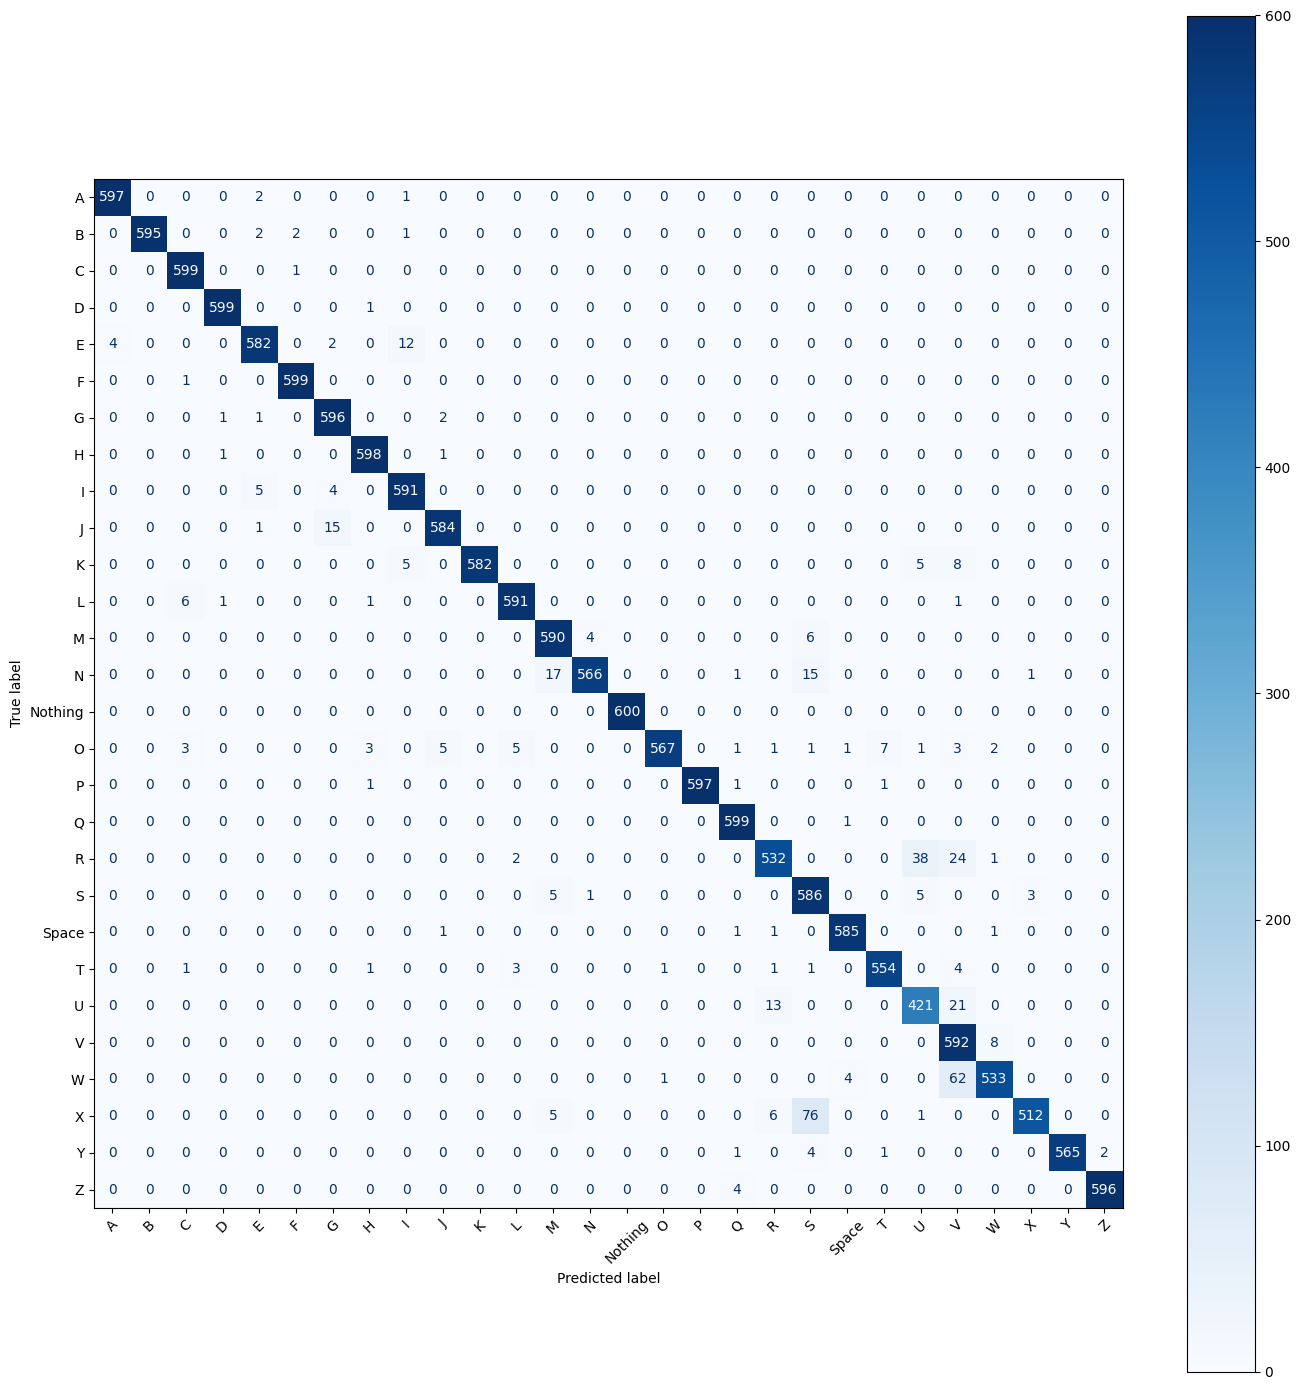

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=signs)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.tight_layout()
plt.show()

Finalmente, revisamos el accuracy por categoría para desglosar las mejoras en el accuracy global del modelo.

Encontramos los siguientes patrones:
* **X** es ahora nuestro accuracy más bajo en ~ 0.85.
* **R, Y** y **W** siguen siendo de los accuracies más bajos.
* Los accuracies de **T** e **Y** mejoraron significativamente.

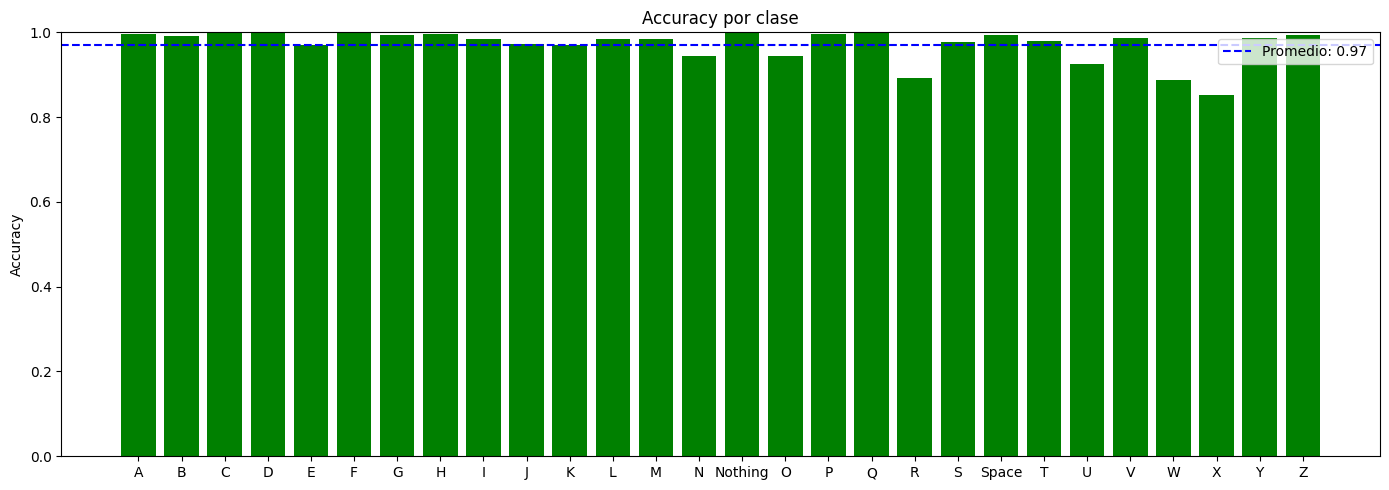

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(14, 5))
bars = plt.bar(signs, per_class_acc, color=['green' if a > 0.7 else 'orange' if a > 0.4 else 'red' for a in per_class_acc])
plt.axhline(y=per_class_acc.mean(), color='blue', linestyle='--', label=f'Promedio: {per_class_acc.mean():.2f}')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy por clase")
plt.legend()
plt.tight_layout()
plt.show()

#### **Diagnóstico final**: fitting

Nuestro modelo al fin tiene un accuracy parejo entre train, val y test. Además, al revisar el rendimiento en símbolos específicos, todas las categorías tienen rendimiento parejo. Aunque existen categorías débiles, sus diferencias en rendimiento con el resto de las categorías son mucho menores. Esto nos indica que nuestro modelo está aprendiendo las categorías y puede generalizar, aunque siguen existiendo áreas de mejora en los hiperparámetros para hacer más fuertes las categorías débiles.

## Bibliografía
[1]: P. Moon, G. Yenurkar, V. O. Nyangaresi, A. Raut, N. Dapkekar, J. Rathod, and P. Dabare, "An improved custom convolutional neural network based hand sign recognition using machine learning algorithm," *Engineering Reports*, vol. 6 no. 10, Feb. 2024. doi: 10.1002/eng2.12878. [Online]. Available: https://onlinelibrary.wiley.com/doi/epdf/10.1002/eng2.12878?getft_integrator=scopus&src=getftr.
‌

[2]: S. B. S. Mugdha, H. Das, M. Uddin, M. E. Arafat, and M. M. Islam, "DeafTech Vision: A Visual Computer's Approach to Accessible Communication through Deep Learning-Driven ASL Analysis," *Stat., Optim. Inf. Comput.*, vol. 12, no. 6, pp. 1795–1811, Jun. 2024. doi: 10.19139/soic-2310-5070-2020. [Online]. Available: https://iapress.org/index.php/soic/article/view/2020/1120.

[3]: B. Alsharif, E. Alalwany, A. Ibrahim, I. Mahgoub, and M. Ilyas, "Real-Time American Sign Language Interpretation Using Deep Learning and Keypoint Tracking," *Sensors*, vol. 25, Mar 2025. doi: 10.3390/s25072138. [Online]. Available: https://www.mdpi.com/1424-8220/25/7/2138.

[4]: A. N. Fierro Radilla, K. R. Perez Daniel, G. Benitez Garcia, P. Najera Garcia, and R. Fuentes Valdez, "Similarity Learning for CNN-Based ASL Alphabet Recognition," *Frontiers in Artificial Intelligence and Applications*, vol. 337, pp. 633-645, 2021. doi: 10.3233/faia210060.

[5]: P. Das, T. Ahmed, and M. F. Ali, "Static Hand Gesture Recognition for American Sign Language Using Deep Convolutional Neural Network," *2020 IEEE Region 10 Symposium (TENSYMP)*, pp. 1795–1811, June 2020. doi: 10.1109/TENSYMP50017.2020.9230772. [Online]. Available: https://ieeexplore.ieee.org/document/9230772.